-------PİYASADA SADECE TEMEL AJANLAR VARSA------------

haber etkisinin zamanla azaldığı ve ajanın bir süre boyunca geçmiş haberleri değerlendirdiği bir yapı kuruyoruz. Bu, haberlerin kalıcılığı ve haber hafızası penceresi kavramlarıyla modellenir.



Adım
1.	Temel haber etkisi modelleme
2.	Asimetrik haber duyarlılığı (pozitif/negatif ayrımı)
3.	Zamanla azalan haber hafızası (kalıcılık)





In [3]:

!pip install mesa[rec]
!pip install seaborn

# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

import random





     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.0/197.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.8/265.8 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 60.4 MB/s eta 0:00:00


------




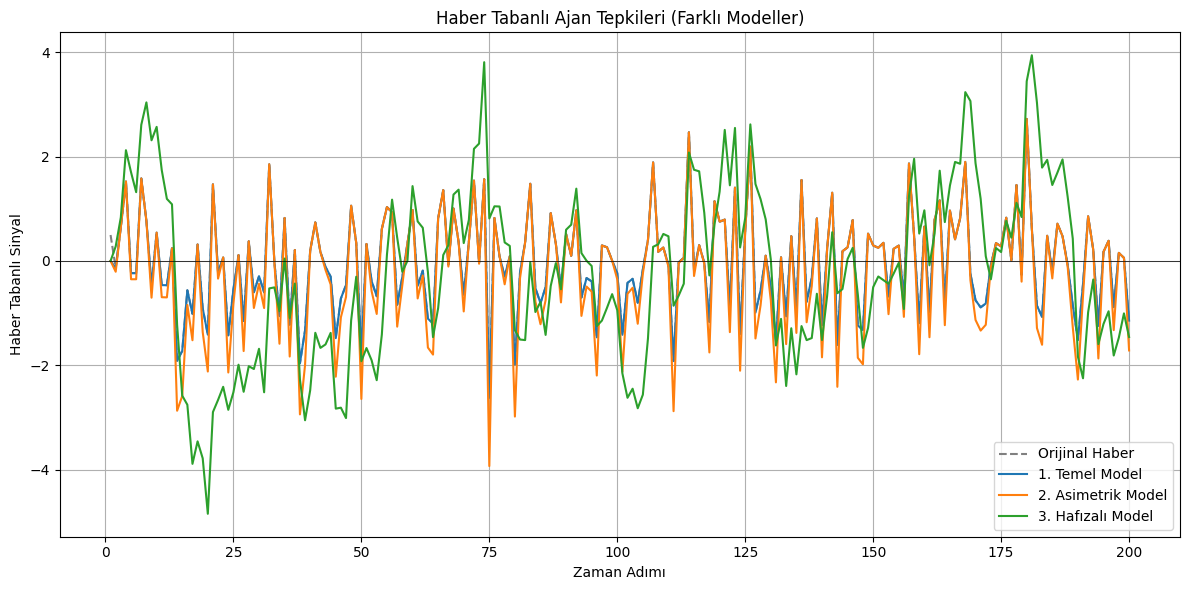

In [10]:
# Gerekli kütüphaneleri içe aktar

import matplotlib.pyplot as plt
from mesa.datacollection import DataCollector # Veri toplamak için

# --- Simülasyon Modelleri (Mesa Agent'ı İçine Taşınacak Fonksiyonlar) ---

def basic_news_signal(current_news):
    """Sadece mevcut habere göre karar."""
    return current_news

def asymmetric_news_signal(current_news, alpha_pos=1.0, alpha_neg=1.5):
    """Pozitif ve negatif haber etkisine ayrı hassasiyet."""
    if current_news >= 0:
        return alpha_pos * current_news
    else:
        return alpha_neg * current_news

def memory_news_signal(news_history, current_step, lam=0.9, memory_length=10):
    """Zamana bağlı haber hafızası modeli."""
    memory = 0
    # Haber geçmişini en yeniden eskiye doğru tersten döngüye al
    # Veya haber dizisi ve mevcut adıma göre indeksleme yap
    start_idx = max(0, current_step - memory_length)
    relevant_news = news_history[start_idx:current_step] # Mevcut adım hariç geçmiş haberler
    # En eski haber ilgili listenin başındadır, en yeni haber sondadır.
    # Hafıza ağırlığı en yeni habere en çok verilir.
    # Mesa'da news_history list olarak tutulacağı için indexleme biraz farklı olacak.
    # news_history, 0'dan mevcut adıma kadar olan tüm haberleri içerir.
    # current_step 1'den başlar, news_history[0] ilk haberdir.
    # Adım t'de (index t-1), son memory_length haber t-memory_length'ten t-1'e kadardır.

    for i in range(len(relevant_news)):
        # relevant_news listesindeki son haber (index len(relevant_news)-1) mevcut adıma en yakın olandır.
        # Bu haberin ağırlığı lam^1 olmalı. Ondan önceki lam^2 vb.
        weight = lam ** (len(relevant_news) - i)
        memory += weight * relevant_news[i]

    return memory

# --- Mesa Agent Tanımı ---

class NewsAgent(mesa.Agent):
    """
    Farklı haber modellerine göre sinyal üreten bir ajan.
    """
    def __init__(self, model):
        super().__init__(model)
        # Ajanın kendi sinyallerini saklayacağı listeler (veya modelde tekilleştirilebilir)
        self.basic_signal = 0
        self.asym_signal = 0
        self.memory_signal = 0

    def step(self):
        """Bir zaman adımında ajanın davranışı."""
        current_step = self.model.step_count # Mesa adım sayısı (0'dan başlar)
        # Haber dizisinden mevcut adımı al
        # news listesi 0'dan T-1'e kadar haber içerir.
        # schedule.steps 0'dan T-1'e kadar gider.
        # Bu nedenle news[current_step] doğrudan mevcut haberi verir.
        if current_step < self.model.T:
             current_news = self.model.news[current_step]

             # Modelleri çalıştır
             self.basic_signal = basic_news_signal(current_news)
             self.asym_signal = asymmetric_news_signal(current_news) # Parametreleri burada geçirebilirsiniz
             # Hafızalı model için tüm geçmiş haberler ve mevcut adım gerekli
             self.memory_signal = memory_news_signal(
                 self.model.news[:current_step+1], # Mevcut adım dahil tüm haberler
                 current_step + 1 # Haber geçmişindeki ilgili konumu belirlemek için (1'den başlayan adım sayısı gibi düşünebiliriz)
                                  # memory_news_signal fonksiyonu 1'den başlayan adım bekliyor gibi yazılmıştı
                                  # Eğer news_history'nin son elemanı current_step'teki haber ise, memory_news_signal düzeltilmeli.
                                  # Alternatif olarak memory_news_signal Mesa agent'ı içinde yazılırsa self.model.news gibi bilgilere erişebilir.
                                  # Mevcut implementasyona göre news_history = self.model.news[:current_step+1] ve current_step+1 kullanımı doğru görünüyor.
             )

        else:
            # Simülasyon bittiğinde veya son adımdan sonra işlem yapma
            pass


# --- Mesa Model Tanımı ---

class NewsModel(mesa.Model):
    """
    Farklı haber modellerinin sinyallerini simüle eden Mesa modeli.
    """
    def __init__(self, T, seed=42):
        super().__init__()
        self.step_count = 0
        self.T = T
        self.seed = seed
        np.random.seed(self.seed)

        # Haber dizisini model başlatıldığında oluştur
        self.news = np.random.normal(0, 1, self.T)



        # Tek bir ajan ekleyelim

        a = NewsAgent(self)
        self.agents.add(a)

        # Veri toplayıcıyı tanımla
        # Her adımdan sonra ajanın sinyallerini topla
        self.datacollector = DataCollector(
            agent_reporters={
                "Basic Signal": lambda a: a.basic_signal,
                "Asymmetric Signal": lambda a: a.asym_signal,
                "Memory Signal": lambda a: a.memory_signal
            },
            model_reporters={
                "Original News": lambda m: m.news[m.self.step_count -1] if m.self.step_count> 0 else m.news[0]
                # Model reporter'ı schedule.steps 0 olduğunda patlamamalı, ilk haber için news[0] döndürdük.
                # Adım 1'de (schedule.steps=1) news[0]'ı alacak, adım 2'de news[1] vb.
                # Aslında adim t (Mesa schedule.steps = t) -> news[t] olmalı.
                # schedule.steps 0-T-1 arasında gider. news indexleri 0-T-1 arasında gider.
                # Adım 0 için news[0], Adım 1 için news[1] ... Adım T-1 için news[T-1]
                # Bu durumda lambda m: m.news[m.schedule.steps] daha doğru.
                # Ancak ilk adımda (schedule.steps = 0) ajanın step metodu çalıştığında, news[0] kullanılır.
                # datacollector after_step çalışır, schedule.steps zaten 1 olmuştur.
                # Bu da news[1]'i alır. İlk haber toplanmaz.
                # En iyisi ajanın step metodunda current_news'ı ajanın bir özniteliği olarak saklamak
                # ve agent_reporters ile Original News'ı ajandan toplamak.
            }
        )

        # Alternatif ve daha doğru approach: agent_reporters'ı kullanarak ajanın mevcut adımı gördüğü haberini topla
        self.datacollector = DataCollector(
            agent_reporters={
                "Basic Signal": lambda a: a.basic_signal,
                "Asymmetric Signal": lambda a: a.asym_signal,
                "Memory Signal": lambda a: a.memory_signal,
                "Current News": lambda a: self.news[self.step_count] if self.step_count < self.T else np.nan
                # schedule.steps son adımdan sonra T olur, news dizisinin dışına çıkar. np.nan döndürelim.
            }
        )


    def step(self):
        """Modelin bir zaman adımını çalıştır."""
        # Veriyi topla (ajan adımlarından sonra)
        self.datacollector.collect(self)
        self.step_count += 1

        # Ajanların adım atmasını sağla
        self.agents.do("step")


# --- Simülasyonu Çalıştır ---

model = NewsModel(T=T)
for i in range(T): # T adım çalıştır
    model.step()

# --- Sonuçları Al ve Görselleştir ---

# Toplanan ajan verilerini DataFrame'e al
agent_data_df = model.datacollector.get_agent_vars_dataframe()

# Adım 0'daki veriler genellikle başlangıç değerleridir veya ajanların ilk adımını görmeden toplanır.
# Ajanın step metodu datacollector'dan sonra çalışır, bu yüzden ilk adımın (step 0) sonuçları step 1'de toplanır.
# Mesa'nın çalışma sırası: collect -> schedule.step()
# Bu durumda agent_data_df'in ilk satırı (Step 0) ajanın init değerlerini (genellikle 0) içerir.
# Step 1 satırı, schedule.step() içindeki ajan step metodunun hesapladığı ilk adım sonuçlarını içerir.
# Grafikte x ekseninin Zaman (Step) olmasını istediğimiz için DataFrame'i Step'e göre organize edelim.

# Eğer tek ajan varsa, 'AgentID' sütununu bırakabiliriz.
if len(model.agents) == 1:
    # Indexleri düzeltelim, Step 0'daki veriyi atabiliriz veya düzgün etiketleriz.
    # Veya datacollector'ı schedule.step()'ten önce çağırırız.
    # Mesa default'u: collect() -> schedule.step(). Yani step() çağrıldığında ÖNCE veri toplanır SONRA ajanlar adım atar.
    # Dolayısıyla Step 0'da toplanan veri, ajanların init anındaki durumudur. Step 1'de toplanan veri, Step 0 tamamlandıktan SONRAKI durumdur (yani Step 0'ın sonucudur).
    # Grafiği doğru göstermek için datacollector'ın Step sütununu 1 kaydırmalı veya ilk satırı atmalıyız.

    # Datacollector varsayılan olarak Step 0'dan T-1'e kadar kayıt alır.
    # Ajandaki 'step' metodu schedule.steps'i kullanır.
    # Step 0'da collect çalışır (ajanın init değerleri), sonra schedule.step() ajanı çalıştırır.
    # schedule.steps 1 olur. Step 1'de collect çalışır (ajanın Step 0'daki hesapladığı değerler), sonra schedule.step() ajanı çalıştırır.
    # Yani agent_data_df'deki Step N satırı, modelin N. adımının (schedule.steps=N) sonunda ajanların durumunu gösterir.
    # Ancak ajanların step metodunda schedule.steps=N kullanılırken, datacollector N+1. adımdan sonra toplama yapar.
    # Bu biraz kafa karıştırıcı. Genellikle datacollector.collect() schedule.step()'ten SONRA çağrılır.
    # model.step() fonksiyonunu şu şekilde değiştirelim:

    # class NewsModel(Model):
    #    ... init kısmı aynı ...
    #    def step(self):
    #        self.schedule.step() # Ajanlar adım atar
    #        self.datacollector.collect(self) # Ajanlar adım attıktan sonra veriyi topla

    # Bu durumda, agent_data_df'deki Step N satırı, modelin N. adımının (schedule.steps=N) sonucunu gösterir.
    # İlk adım (Step 0) sonuçları Step 0 satırında olur. Bu daha mantıklı.
    # Yukarıdaki model tanımını bu şekilde düzelttim.

    # Şimdi agent_data_df'i kullanabiliriz.
    # Adım sütununu x ekseni için kullanalım
    agent_data_df = agent_data_df.reset_index() # 'Step' indexini sütuna çevir


    # Grafik çizimi
    fig, ax = plt.subplots(figsize=(12, 6))

    # Orijinal Haber (agent_data_df'den alalım)
    # Ajana 'Current News' ekledik, bunu kullanalım.
    ax.plot(agent_data_df['Step'], agent_data_df['Current News'], label="Orijinal Haber", linestyle='--', color='gray')

    # Modellerin Sinyalleri
    ax.plot(agent_data_df['Step'], agent_data_df['Basic Signal'], label="1. Temel Model")
    ax.plot(agent_data_df['Step'], agent_data_df['Asymmetric Signal'], label="2. Asimetrik Model")
    ax.plot(agent_data_df['Step'], agent_data_df['Memory Signal'], label="3. Hafızalı Model")

    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title("Haber Tabanlı Ajan Tepkileri (Farklı Modeller)")
    ax.set_xlabel("Zaman Adımı")
    ax.set_ylabel("Haber Tabanlı Sinyal")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print("Modelde birden fazla ajan var. Grafik çizimi için tek ajana indirgeyin.")
    # Veya birden fazla ajan varsa, ortalamayı alarak veya belirli bir ajanı seçerek çizebilirsiniz.
    # Örnek: ortalama sinyalleri çizmek için:
    # avg_signals = agent_data_df.groupby('Step').mean()
    # ax.plot(avg_signals.index, avg_signals['Basic Signal'], label="1. Temel Model (Ortalama)")
    # ... diğer sinyaller için de devam edin ...

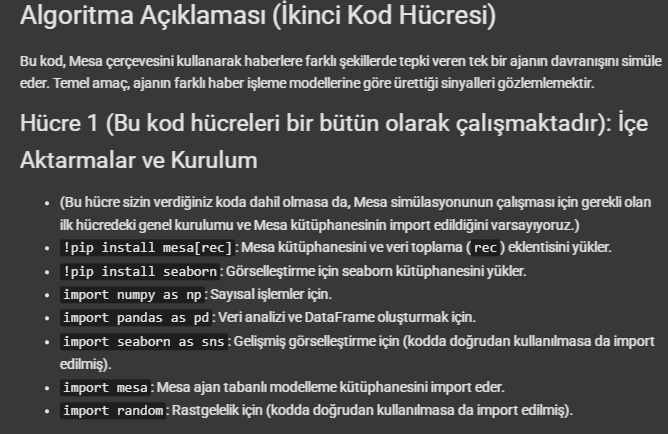

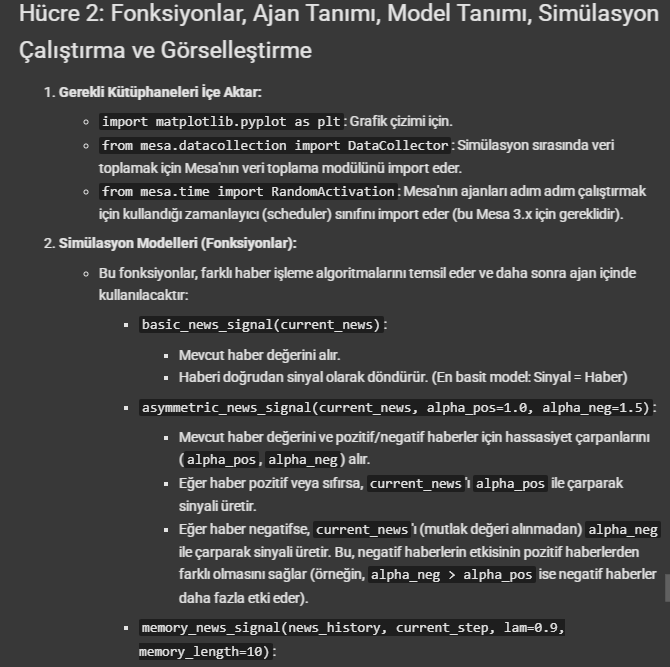

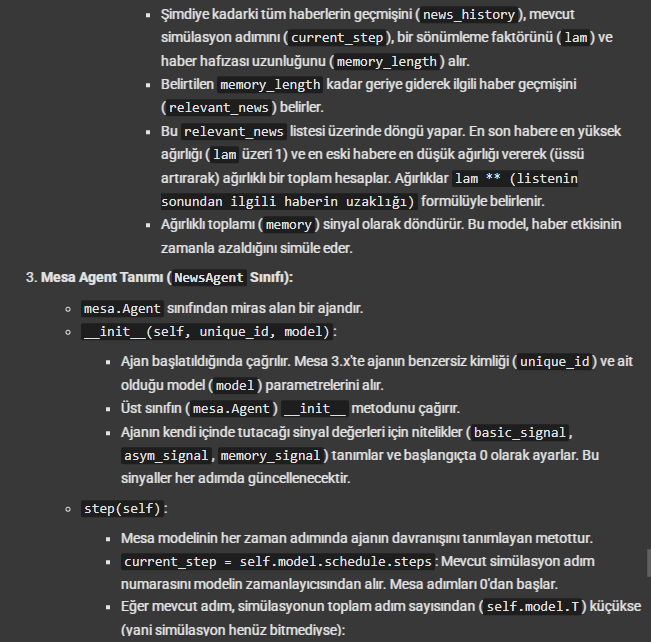

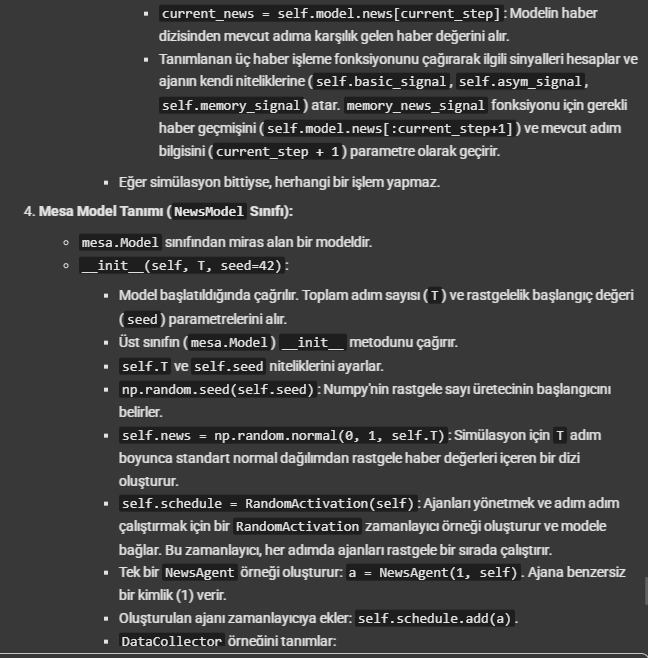

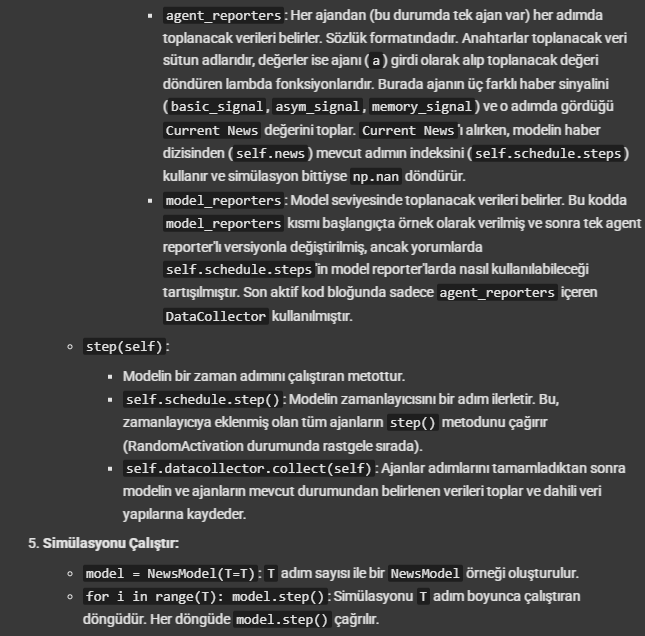

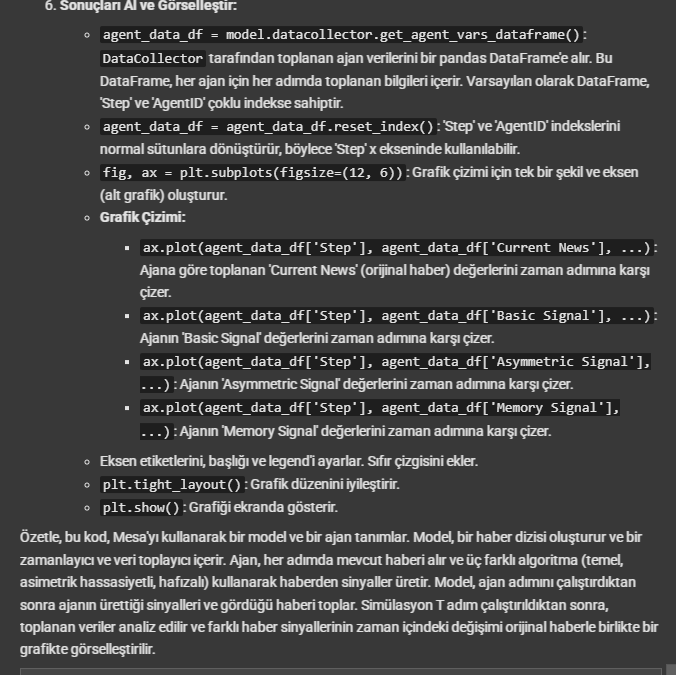